In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
 
import warnings
warnings.filterwarnings('ignore')

In [3]:
print("=" * 55)
print("STEP 1 — DATA SETUP & EDA")
print("=" * 55)
 
df = pd.read_csv('fertility.csv')
 
print("\n---- Shape ----")
print(df.shape)
 
print("\n---- Info ----")
df.info()

print("\n---- Describe ----")
print(df.describe())
 
print("\n---- Target Distribution ----")
print(df['output'].value_counts())

STEP 1 — DATA SETUP & EDA

---- Shape ----
(100, 10)

---- Info ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   season                 100 non-null    float64
 1   age                    100 non-null    float64
 2   childish-disease       100 non-null    int64  
 3   trauma                 100 non-null    int64  
 4   surgical-intervention  100 non-null    int64  
 5   fevers                 100 non-null    int64  
 6   alcoholic              100 non-null    float64
 7   smoking                100 non-null    int64  
 8   sitting                100 non-null    float64
 9   output                 100 non-null    object 
dtypes: float64(4), int64(5), object(1)
memory usage: 7.9+ KB

---- Describe ----
           season         age  childish-disease      trauma  \
count  100.000000  100.000000        100.000000  100.00000

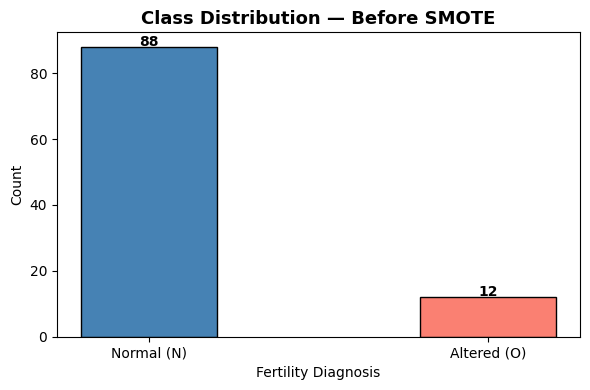

Saved: graph1_class_distribution_before_smote.png

── Feature Variances (justifies PCA — low-variance features add noise) ──
season                   0.6348
age                      0.0147
childish-disease         0.1142
trauma                   0.2489
surgical-intervention    0.2524
fevers                   0.3373
alcoholic                0.0281
smoking                  0.6540
sitting                  0.0347
dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['output'].value_counts()
ax.bar(counts.index, counts.values,
       color=['steelblue', 'salmon'], edgecolor='black', width=0.4)
ax.set_title('Class Distribution — Before SMOTE', fontsize=13, fontweight='bold')
ax.set_xlabel('Fertility Diagnosis')
ax.set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 0.3, str(val), ha='center', fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Normal (N)', 'Altered (O)'])
plt.tight_layout()
plt.savefig('graph1_class_distribution_before_smote.png', dpi=150)
plt.show()
print("Saved: graph1_class_distribution_before_smote.png")
 
# --- Print feature variances (justify PCA) ---
print("\n── Feature Variances (justifies PCA — low-variance features add noise) ---")
print(df.drop(columns='output').var().round(4))
 

In [ ]:
print("\n" + "=" * 55)
print("STEP 2 — DATA PREPROCESSING")
print("=" * 55)
 
# Missing values check
print("\n--- Missing Values ---")
print(df.isnull().sum())    


STEP 2 — DATA PREPROCESSING

── Missing Values ──
season                   0
age                      0
childish-disease         0
trauma                   0
surgical-intervention    0
fevers                   0
alcoholic                0
smoking                  0
sitting                  0
output                   0
dtype: int64


In [10]:
# Encode target: N → 0, O → 1
le_target = LabelEncoder()
df['output'] = le_target.fit_transform(df['output'])   # N=0, O=1
print("\n--- Target Encoding: N → 0, O (Altered) → 1 ---")
print(df['output'].value_counts())

# Encode 'season' column using LabelEncoder
le_season = LabelEncoder()
df['season'] = le_season.fit_transform(df['season'])
print("\n--- Season encoded with LabelEncoder ---")
print("Unique season values after encoding:", df['season'].unique()) 


--- Target Encoding: N → 0, O (Altered) → 1 ---
output
0    88
1    12
Name: count, dtype: int64

--- Season encoded with LabelEncoder ---
Unique season values after encoding: [1 3 0 2]


In [12]:
# Features and target
X = df.drop(columns='output')
y = df['output']


# --- SPLIT FIRST — before any scaling ---
# The scaler must only learn from training data.
# If we scaled before splitting, the scaler would see val/test min & max
# — that is data leakage. So: split first, scale after.
 
# Step 1: split off 40% as a temporary hold-out (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,          # 40% goes to temp (will become val + test)
    random_state=42,
    stratify=y
)
# Step 2: split the 40% temp evenly → 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,          # 50% of 40% = 20% of total
    random_state=42,
    stratify=y_temp
)
print(f"\n--- 60 / 20 / 20 Train / Validation / Test Split ---")
print(f"  Train      samples : {X_train.shape[0]}  (60%)")
print(f"  Validation samples : {X_val.shape[0]}   (20%)")
print(f"  Test       samples : {X_test.shape[0]}   (20%)")
 


--- 60 / 20 / 20 Train / Validation / Test Split ---
  Train      samples : 60  (60%)
  Validation samples : 20   (20%)
  Test       samples : 20   (20%)


In [13]:
# --- SCALE AFTER SPLITTING — fit on train only ---
# fit_transform on train : scaler LEARNS the min & max from training data
# transform on val/test  : applies those SAME min & max values (no re-learning)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)   # learn min/max FROM train only
X_val   = scaler.transform(X_val)         # apply same scale to val
X_test  = scaler.transform(X_test)        # apply same scale to test
print("\n--- MinMaxScaler: fit on train only, transformed val and test ---")
 


--- MinMaxScaler: fit on train only, transformed val and test ---



── PCA (95% variance threshold) ---
  Original features  : 9
  PCA components kept: 8
  Explained variance ratios: [0.251 0.221 0.157 0.122 0.092 0.061 0.045 0.03 ]
  Total variance retained  : 0.9797


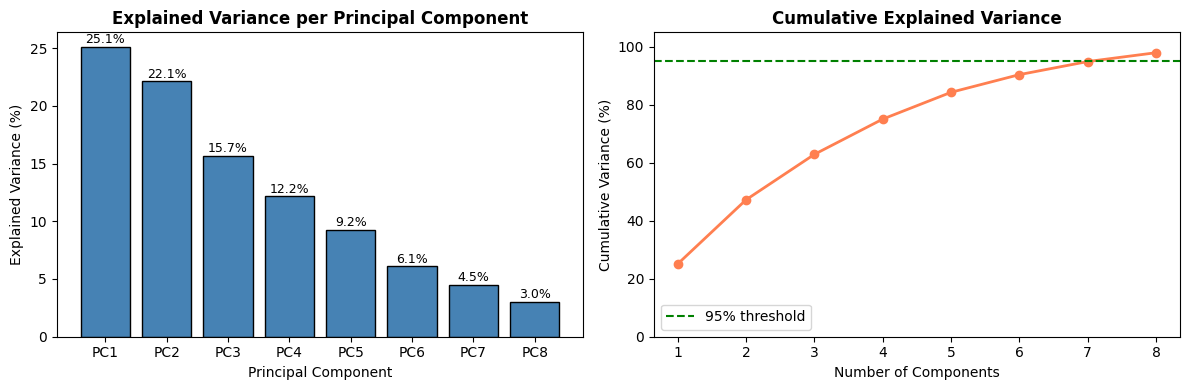

Saved: graph_scree_plot.png (Unique Graph — Scree Plot)


In [14]:
# --- PCA — fit ONLY on train, transform all three sets ---
# n_components=0.95 keeps enough components to explain 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)   # learn PCA from train only
X_val_pca   = pca.transform(X_val)         # apply to validation
X_test_pca  = pca.transform(X_test)        # apply to test
 
print(f"\n── PCA (95% variance threshold) ---")
print(f"  Original features  : {X_train.shape[1]}")
print(f"  PCA components kept: {pca.n_components_}")
print(f"  Explained variance ratios: "
      f"{np.round(pca.explained_variance_ratio_, 3)}")
print(f"  Total variance retained  : "
      f"{pca.explained_variance_ratio_.sum():.4f}")
 
# --- Unique Graph A : Scree Plot of PCA explained variance ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Left — per-component bar
components = [f"PC{i+1}" for i in range(pca.n_components_)]
axes[0].bar(components, pca.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='black')
axes[0].set_title('Explained Variance per Principal Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i, v * 100 + 0.3, f"{v*100:.1f}%", ha='center', fontsize=9)
 
# Right — cumulative variance line
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cumvar) + 1), cumvar,
             marker='o', color='coral', linewidth=2)
axes[1].axhline(y=95, color='green', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_ylim([0, 105])
axes[1].legend()
axes[1].set_xticks(range(1, len(cumvar) + 1))
 
plt.tight_layout()
plt.savefig('graph_scree_plot.png', dpi=150)
plt.show()
print("Saved: graph_scree_plot.png (Unique Graph — Scree Plot)")


STEP 3 — HANDLING CLASS IMBALANCE

── Class counts BEFORE SMOTE (training set) ──
  Normal (0): 53
  Altered (1): 7

── Class counts AFTER SMOTE (training set) ──
  Normal (0): 53
  Altered (1): 53


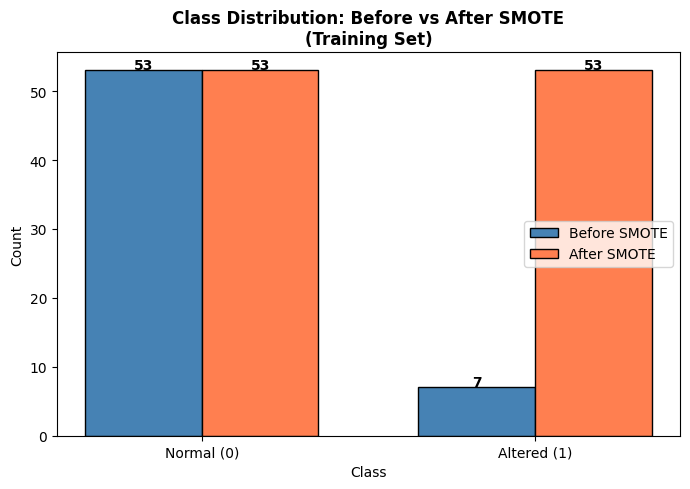

Saved: graph2_smote_distribution.png


In [15]:
print("\n" + "=" * 55)
print("STEP 3 — HANDLING CLASS IMBALANCE")
print("=" * 55)
 
print("\n── Class counts BEFORE SMOTE (training set) ──")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Normal' if u == 0 else 'Altered'
    print(f"  {label} ({u}): {c}")
 
# Apply SMOTE AFTER PCA — only on PCA-transformed TRAINING data
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train_pca, y_train)
 
print("\n── Class counts AFTER SMOTE (training set) ──")
unique_s, counts_s = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique_s, counts_s):
    label = 'Normal' if u == 0 else 'Altered'
    print(f"  {label} ({u}): {c}")
 
# ── Graph 2 (Mandatory) : Class distribution Before vs After SMOTE ──
labels = ['Normal (0)', 'Altered (1)']
before_counts = [counts[0], counts[1]]
after_counts  = [counts_s[0], counts_s[1]]
 
x = np.arange(len(labels))
width = 0.35
 
fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, before_counts, width, label='Before SMOTE',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, after_counts,  width, label='After SMOTE',
               color='coral', edgecolor='black')
 
ax.set_title('Class Distribution: Before vs After SMOTE\n(Training Set)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
 
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(int(bar.get_height())), ha='center', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(int(bar.get_height())), ha='center', fontweight='bold')
 
plt.tight_layout()
plt.savefig('graph2_smote_distribution.png', dpi=150)
plt.show()
print("Saved: graph2_smote_distribution.png")
 